> **Solution version** -- this notebook contains the complete code of all exercises, executed from top to bottom, and answer elements for each observation question. The student version is available on the course webpage.


# PAC-Bayes 1 -- Foundations: Gibbs classifier, majority vote, KL and concentration

This first notebook sets up the objects we will manipulate in the whole PAC-Bayesian part of the course.
An ensemble (bagging, random forest, boosting...) is seen as a **distribution $Q$ over a set of voters**, and we compare the
Gibbs classifier $G_Q$ (draw a voter at random, use it) with the majority vote $B_Q$.
We then look at the two ingredients of every PAC-Bayesian bound: the **KL divergence** between posterior and prior, and
**concentration** of the empirical risk, with the binary kl and its inversion. We finish with the change of measure inequality and the Occam bound.

Lecture notes: Sections 1 and 2.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

rng = np.random.RandomState(0)
plt.rcParams["figure.figsize"] = (6, 4)


## I. Gibbs classifier and majority vote

Let $\mathcal H=\{h_1,\dots,h_n\}$ be a set of voters with values in $\{-1,+1\}$ and $Q=(Q_1,\dots,Q_n)$ a probability vector.

- The **Gibbs classifier** $G_Q$ draws $h\sim Q$ for each new point and predicts $h(x)$. Its risk is the average risk of the voters: $R(G_Q)=\sum_t Q_t\,R(h_t)$.
- The **majority vote** is $B_Q(x)=\mathrm{sign}\big(\sum_t Q_t h_t(x)\big)$.

A random forest is exactly a majority vote with $Q$ uniform over its trees. With scikit-learn, the trees are stored in `rf.estimators_`.
Be careful: the individual trees of a `RandomForestClassifier` predict the *index* of the class (0/1), so we map them to $\{-1,+1\}$.


In [2]:
X, y = make_moons(1000, noise=0.3, random_state=0)
y = 2 * y - 1                                   # labels in {-1,+1}
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.5, random_state=0)

rf = RandomForestClassifier(n_estimators=100, max_features=1, random_state=0).fit(Xtr, ytr)

def votes(forest, X):
    # matrix (n_voters, n_points) of predictions in {-1,+1}
    return np.array([2 * t.predict(X).astype(int) - 1 for t in forest.estimators_])

V = votes(rf, Xte)
Q = np.ones(V.shape[0]) / V.shape[0]            # uniform posterior

risk_voters = (V != yte).mean(axis=1)           # R(h_t) on the test set
gibbs = Q @ risk_voters
mv = np.mean(np.where(Q @ V >= 0, 1, -1) != yte)
print(f"Gibbs risk      : {gibbs:.3f}")
print(f"Majority vote   : {mv:.3f}")
print(f"best / worst tree: {risk_voters.min():.3f} / {risk_voters.max():.3f}")

Gibbs risk      : 0.141
Majority vote   : 0.104
best / worst tree: 0.110 / 0.198



Let us now have a look at the distribution of $W_Q(x,y)=\sum_t Q_t\,\mathbb 1[h_t(x)\neq y]$, the proportion of trees that are wrong on a test point.


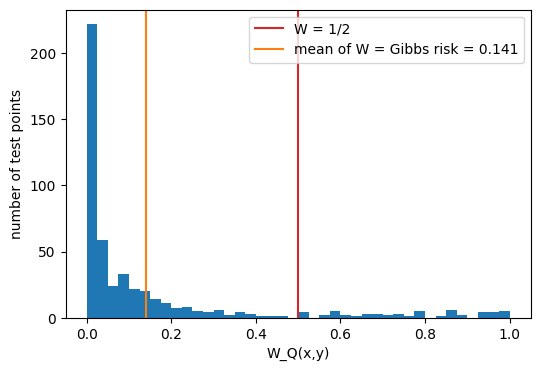

fraction of points with W >= 1/2: 0.106


In [3]:
W = Q @ (V != yte)
plt.hist(W, bins=40, color="C0")
plt.axvline(0.5, color="C3", label="W = 1/2")
plt.axvline(W.mean(), color="C1", label=f"mean of W = Gibbs risk = {W.mean():.3f}")
plt.xlabel("W_Q(x,y)"); plt.ylabel("number of test points"); plt.legend(); plt.show()
print("fraction of points with W >= 1/2:", np.mean(W >= 0.5))

$$ $$

**Question 1:** What is the link between the fraction of points with $W_Q\geq 1/2$ and the risk of the majority vote? And between the mean of $W_Q$ and the Gibbs risk?

$$ $$

*Answer elements.* The majority vote errs exactly when at least half of the ($Q$-weighted) voters err, so $R(B_Q)=\mathbb P(W_Q\geq 1/2)$ (with ties counted as errors). The Gibbs risk is $\mathbb E[W_Q]$ by Fubini. The vote is good when the distribution of $W_Q$ has little mass above $1/2$, even if its mean is not small.


Now, let us vary the diversity of the forest through `max_features` (here the data are 2D, so we add noisy features to make the parameter meaningful).


In [4]:
Xn = np.hstack([X, rng.randn(X.shape[0], 8)])   # 2 informative + 8 noise features
Xtr_n, Xte_n, ytr_n, yte_n = train_test_split(Xn, y, test_size=0.5, random_state=0)
for mf in [1, 2, 5, 10]:
    f = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=0).fit(Xtr_n, ytr_n)
    Vn = votes(f, Xte_n); Qn = np.ones(100) / 100
    g = Qn @ (Vn != yte_n).mean(1)
    b = np.mean(np.where(Qn @ Vn >= 0, 1, -1) != yte_n)
    print(f"max_features={mf:2d}  Gibbs risk={g:.3f}  majority vote={b:.3f}  ratio={b/g:.2f}")

max_features= 1  Gibbs risk=0.318  majority vote=0.142  ratio=0.45


max_features= 2  Gibbs risk=0.250  majority vote=0.132  ratio=0.53


max_features= 5  Gibbs risk=0.186  majority vote=0.112  ratio=0.60


max_features=10  Gibbs risk=0.159  majority vote=0.106  ratio=0.67


$$ $$

**Question 2:** How do the Gibbs risk and the risk of the vote evolve with `max_features`? Which of the two benefits the most from randomization? Relate this to the notion of *diversity*.

$$ $$

*Answer elements.* With few features per split, each tree is weak (large Gibbs risk) but the trees are very different from each other, and the vote corrects a large part of their errors (small ratio). With `max_features=10` the trees are strong but correlated, the Gibbs risk decreases but the gain of the vote is small. The risk of the vote depends on both the strength and the diversity of the voters: this is what Section 5 of the lecture notes formalizes.


## II. The KL divergence

For two distributions on a finite set of voters, $\mathrm{KL}(Q\|P)=\sum_t Q_t\ln\frac{Q_t}{P_t}$ (with $0\ln 0=0$).
With a uniform prior over $n$ voters, $\mathrm{KL}(Q\|P)=\ln n - H(Q)$ where $H$ is the entropy: the KL is small for spread-out posteriors, and maximal ($\ln n$) for a Dirac.


In [5]:
def kl_div(q, p):
    q, p = np.asarray(q, float), np.asarray(p, float)
    mask = q > 0
    return np.sum(q[mask] * np.log(q[mask] / p[mask]))

n = 100
P = np.ones(n) / n
for k in [100, 50, 10, 1]:
    Qk = np.zeros(n); Qk[:k] = 1 / k           # uniform over k voters
    print(f"Q uniform over {k:3d} voters: KL = {kl_div(Qk, P):.3f}   (ln(n/k) = {np.log(n / k):.3f})")

Q uniform over 100 voters: KL = 0.000   (ln(n/k) = 0.000)
Q uniform over  50 voters: KL = 0.693   (ln(n/k) = 0.693)
Q uniform over  10 voters: KL = 2.303   (ln(n/k) = 2.303)
Q uniform over   1 voters: KL = 4.605   (ln(n/k) = 4.605)



For Gaussian distributions with the same covariance $\sigma^2 I_d$ we have the closed form
$\mathrm{KL}\big(\mathcal N(\mu_1,\sigma^2 I)\,\|\,\mathcal N(\mu_0,\sigma^2 I)\big)=\frac{\|\mu_1-\mu_0\|^2}{2\sigma^2}$.
A KL is an expectation under $Q$, so it can also be estimated by Monte Carlo: $\frac1N\sum_j \ln\frac{q(\theta_j)}{p(\theta_j)}$ with $\theta_j\sim Q$.
Here is the Monte Carlo estimate in dimension 1 for two Gaussians with *different* variances.


In [6]:
from scipy.stats import norm
mu1, s1, mu0, s0 = 1.0, 0.5, 0.0, 1.0
theta = rng.normal(mu1, s1, 200000)
kl_mc = np.mean(norm.logpdf(theta, mu1, s1) - norm.logpdf(theta, mu0, s0))
kl_exact = np.log(s0 / s1) + (s1**2 + (mu1 - mu0)**2) / (2 * s0**2) - 0.5
print(f"Monte Carlo: {kl_mc:.4f}   closed form: {kl_exact:.4f}")

Monte Carlo: 0.8211   closed form: 0.8181



### Exercise 1

Write a function `kl_gauss(mu1, mu0, sigma)` returning the closed form for $d$-dimensional Gaussians with covariance $\sigma^2 I_d$,
and check it against a Monte Carlo estimate for $d=5$, random means and $\sigma=0.7$ (use `np.testing.assert_allclose` with a relative tolerance of a few percent).


In [7]:
from scipy.stats import multivariate_normal

def kl_gauss(mu1, mu0, sigma):
    return np.sum((np.asarray(mu1) - np.asarray(mu0))**2) / (2 * sigma**2)

d, sigma = 5, 0.7
mu1, mu0 = rng.randn(d), rng.randn(d)
theta = mu1 + sigma * rng.randn(100000, d)
logq = multivariate_normal(mu1, sigma**2 * np.eye(d)).logpdf(theta)
logp = multivariate_normal(mu0, sigma**2 * np.eye(d)).logpdf(theta)
kl_mc = np.mean(logq - logp)
print(f"closed form {kl_gauss(mu1, mu0, sigma):.4f}   Monte Carlo {kl_mc:.4f}")
np.testing.assert_allclose(kl_mc, kl_gauss(mu1, mu0, sigma), rtol=0.05)

closed form 4.4407   Monte Carlo 4.4511



## III. Concentration: Hoeffding versus the binary kl

For a **fixed** voter $h$ with true risk $p$, the empirical risk $\hat p$ on $m$ i.i.d. examples satisfies

- Hoeffding: with probability $\geq 1-\delta$, $p\leq \hat p+\sqrt{\ln(1/\delta)/(2m)}$;
- Chernoff / kl: with probability $\geq 1-\delta$, $\mathrm{kl}(\hat p\|p)\leq \ln(1/\delta)/m$ when $\hat p<p$, i.e. $p\leq \overline{\mathrm{kl}}^{-1}(\hat p,\ln(1/\delta)/m)$,

where $\mathrm{kl}(q\|p)=q\ln\frac qp+(1-q)\ln\frac{1-q}{1-p}$ and $\overline{\mathrm{kl}}^{-1}(q,\varepsilon)=\sup\{p\geq q:\ \mathrm{kl}(q\|p)\leq\varepsilon\}$.
The inversion has no closed form, but $p\mapsto \mathrm{kl}(q\|p)$ is increasing on $[q,1]$, so a bisection does the job.
Here is the **lower** inversion $\underline{\mathrm{kl}}^{-1}(q,\varepsilon)=\inf\{p\leq q:\ \mathrm{kl}(q\|p)\leq\varepsilon\}$.


In [8]:
def kl_bin(q, p):
    p = min(max(p, 1e-12), 1 - 1e-12)
    t1 = q * np.log(q / p) if q > 0 else 0.0
    t2 = (1 - q) * np.log((1 - q) / (1 - p)) if q < 1 else 0.0
    return t1 + t2

def kl_inv_lower(q, eps, tol=1e-9):
    lo, hi = 0.0, q
    while hi - lo > tol:
        mid = (lo + hi) / 2
        if kl_bin(q, mid) > eps:
            lo = mid          # mid is too far from q: the answer is above mid
        else:
            hi = mid
    return lo

print(kl_inv_lower(0.3, 0.05))

0.17126174569129948



### Exercise 2

Write `kl_inv_upper(q, eps)` computing $\overline{\mathrm{kl}}^{-1}(q,\varepsilon)$ by bisection, and check that
(i) `kl_bin(q, kl_inv_upper(q, eps))` is equal to `eps` (up to the tolerance) for $q=0.1,\ \varepsilon=0.05$,
(ii) it is always smaller than the Pinsker relaxation $q+\sqrt{\varepsilon/2}$.


In [9]:
def kl_inv_upper(q, eps, tol=1e-9):
    lo, hi = q, 1.0
    while hi - lo > tol:
        mid = (lo + hi) / 2
        if kl_bin(q, mid) > eps:
            hi = mid
        else:
            lo = mid
    return hi

p_up = kl_inv_upper(0.1, 0.05)
print(p_up, kl_bin(0.1, p_up))
np.testing.assert_allclose(kl_bin(0.1, p_up), 0.05, atol=1e-6)
for q in np.linspace(0, 0.9, 10):
    for eps in [0.001, 0.01, 0.1]:
        assert kl_inv_upper(q, eps) <= q + np.sqrt(eps / 2) + 1e-9
print("kl inversion always tighter than Pinsker: OK")

0.22007860168814664 0.050000000406610956
kl inversion always tighter than Pinsker: OK



We can now check the **coverage** of both bounds by simulation: we draw many samples of size $m$ from a Bernoulli($p$) "voter",
compute both upper bounds, and count how often the true risk $p$ is above the bound (it should happen with frequency $\leq\delta$).


In [10]:
def coverage(p, m, delta=0.05, n_rep=2000):
    fails_h, fails_kl, width_h, width_kl = 0, 0, [], []
    for _ in range(n_rep):
        ph = rng.binomial(m, p) / m
        bh = ph + np.sqrt(np.log(1 / delta) / (2 * m))
        bk = kl_inv_upper(ph, np.log(1 / delta) / m)
        fails_h += p > bh; fails_kl += p > bk
        width_h.append(bh - ph); width_kl.append(bk - ph)
    return fails_h / n_rep, fails_kl / n_rep, np.mean(width_h), np.mean(width_kl)

for p in [0.01, 0.1, 0.3]:
    for m in [50, 500]:
        fh, fk, wh, wk = coverage(p, m)
        print(f"p={p:4.2f} m={m:4d} | failure rate Hoeffding {fh:.3f}  kl {fk:.3f} | mean gap Hoeffding {wh:.3f}  kl {wk:.3f}")

p=0.01 m=  50 | failure rate Hoeffding 0.000  kl 0.000 | mean gap Hoeffding 0.173  kl 0.073


p=0.01 m= 500 | failure rate Hoeffding 0.000  kl 0.007 | mean gap Hoeffding 0.055  kl 0.015


p=0.10 m=  50 | failure rate Hoeffding 0.000  kl 0.007 | mean gap Hoeffding 0.173  kl 0.131


p=0.10 m= 500 | failure rate Hoeffding 0.000  kl 0.006 | mean gap Hoeffding 0.055  kl 0.036


p=0.30 m=  50 | failure rate Hoeffding 0.002  kl 0.004 | mean gap Hoeffding 0.173  kl 0.168


p=0.30 m= 500 | failure rate Hoeffding 0.005  kl 0.008 | mean gap Hoeffding 0.055  kl 0.052


$$ $$

**Question 3:** Are both bounds valid (failure rate $\leq\delta=0.05$)? For which values of $p$ is the kl bound much tighter than Hoeffding's? Why is this important for classifiers with small error?

$$ $$

*Answer elements.* Both failure rates stay below $0.05$ (they are often much smaller: the bounds are conservative). The kl bound is much tighter when $p$ is small: its width behaves like $\ln(1/\delta)/m$ instead of $\sqrt{\ln(1/\delta)/m}$ (fast rate, refined Pinsker). Good classifiers have small risk, so the kl form gives much better certificates in practice; this is why Seeger's bound is the one used to compute final certificates.


## IV. The change of measure inequality

For any function $\phi$ on $\mathcal H$ and any distributions $P,Q$:
$$\mathbb E_{h\sim Q}\,\phi(h)\ \leq\ \mathrm{KL}(Q\|P)+\ln \mathbb E_{h\sim P}\,e^{\phi(h)},$$
with equality for the Gibbs distribution $Q_\phi(h)\propto P(h)e^{\phi(h)}$. This is the only "trick" of PAC-Bayes: it moves from the data-dependent $Q$ to the fixed $P$.
Let us check it numerically on random posteriors.


In [11]:
n = 20
P = rng.dirichlet(np.ones(n))
phi = 3 * rng.randn(n)
rhs_const = np.log(P @ np.exp(phi))
gaps = []
for _ in range(1000):
    Qr = rng.dirichlet(0.3 * np.ones(n))
    gaps.append(kl_div(Qr, P) + rhs_const - Qr @ phi)
print("smallest gap over 1000 random posteriors:", np.min(gaps))

smallest gap over 1000 random posteriors: 1.0310409799824733



### Exercise 3

Build the Gibbs distribution $Q_\phi$ for the same `P` and `phi`, and check with an `assert` that the inequality is an **equality** for $Q_\phi$.
Which of the random posteriors above came closest? Is it close to $Q_\phi$ (compute its KL to $Q_\phi$)?


In [12]:
Qphi = P * np.exp(phi); Qphi /= Qphi.sum()
lhs = Qphi @ phi
rhs = kl_div(Qphi, P) + np.log(P @ np.exp(phi))
print(lhs, rhs)
np.testing.assert_allclose(lhs, rhs, rtol=1e-10)

best, best_gap = None, np.inf
for _ in range(1000):
    Qr = rng.dirichlet(0.3 * np.ones(n))
    g = kl_div(Qr, P) + rhs_const - Qr @ phi
    if g < best_gap:
        best, best_gap = Qr, g
# the gap is exactly KL(Q || Q_phi)
print("best gap:", best_gap, " KL(best || Q_phi):", kl_div(best, Qphi))
np.testing.assert_allclose(best_gap, kl_div(best, Qphi), rtol=1e-8)

3.3685365074296594 3.36853650742966
best gap: 0.8546960658105616  KL(best || Q_phi): 0.8546960658105619



## V. Warm-up: the Occam bound on a finite set of stumps

With a countable set of voters and a prior $P$, with probability $\geq1-\delta$, for **all** $h$ simultaneously:
$$R(h)\leq \overline{\mathrm{kl}}^{-1}\Big(\hat R_S(h),\ \frac{\ln\frac1{P(h)}+\ln\frac1\delta}{m}\Big).$$
We build a finite set of decision stumps on the `breast_cancer` dataset (thresholds at fixed quantiles of each feature, both orientations) and compute the bound for each stump with the uniform prior.


300 stumps, m=284. Best stump: empirical 0.127, test 0.126, Occam bound 0.223


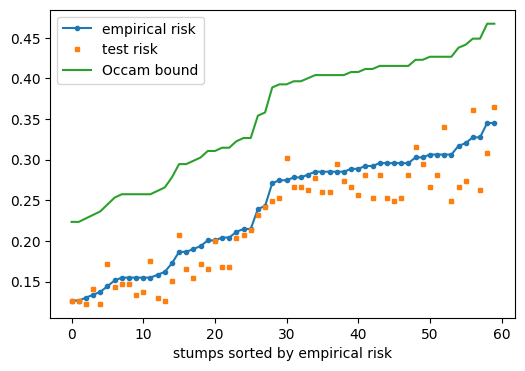

In [13]:
Xb, yb = load_breast_cancer(return_X_y=True)
yb = 2 * yb - 1
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(Xb, yb, test_size=0.5, random_state=0)

stumps = [(j, t, s) for j in range(Xb.shape[1])
          for t in np.quantile(Xb[:, j], [0.1, 0.25, 0.5, 0.75, 0.9])   # quantiles of the full X: they do not use the labels
          for s in (1, -1)]
def stump_votes(X):
    return np.array([s * np.where(X[:, j] > t, 1, -1) for j, t, s in stumps])

Vtr_b, Vte_b = stump_votes(Xtr_b), stump_votes(Xte_b)
emp = (Vtr_b != ytr_b).mean(1); test = (Vte_b != yte_b).mean(1)
m, n_st, delta = len(ytr_b), len(stumps), 0.05
occam = np.array([kl_inv_upper(e, (np.log(n_st) + np.log(1 / delta)) / m) for e in emp])
best = np.argmin(emp)
print(f"{n_st} stumps, m={m}. Best stump: empirical {emp[best]:.3f}, test {test[best]:.3f}, Occam bound {occam[best]:.3f}")
order = np.argsort(emp)[:60]
plt.plot(emp[order], "o-", ms=3, label="empirical risk")
plt.plot(test[order], "s", ms=3, label="test risk")
plt.plot(occam[order], "-", label="Occam bound")
plt.xlabel("stumps sorted by empirical risk"); plt.legend(); plt.show()

$$ $$

**Question 4:** Is the bound valid for the stumps shown (bound above the test risk)? How would the bound change if we used 10 times more stumps? And with a prior that puts more mass on the stumps built on the first 5 features?

$$ $$

*Answer elements.* Yes, the bound is above the test risk for all stumps (as expected with probability $\geq 0.95$). With 10 times more stumps and a uniform prior, $\ln(1/P(h))$ grows by $\ln 10\approx 2.3$ nats: the price is logarithmic, which is why the Occam bound is still reasonable for large finite classes. A non-uniform prior makes some stumps cheaper and others more expensive; it helps only if it was chosen *before* seeing the data and favours the good stumps. Note that the thresholds were built from the inputs only (no labels): if they had been tuned on $S$, the prior would depend on the data and the bound would no longer be valid.


### Exercise 4

The Occam bound certifies a *single* stump. Now take as posterior $Q$ the uniform distribution over the $k$ stumps with the smallest empirical risk, and compute
Seeger's PAC-Bayesian bound $\overline{\mathrm{kl}}^{-1}\big(\hat R_S(G_Q),\ (\mathrm{KL}(Q\|P)+\ln\frac{2\sqrt m}{\delta})/m\big)$ on the Gibbs risk for $k\in\{1,2,5,10,20,50\}$.
Compare with the test Gibbs risk and the test risk of the majority vote of these $k$ stumps. Which $k$ gives the best certificate? the best vote?


In [14]:
# Model: the same computation for the posterior uniform over ALL stumps (Q = P, KL = 0)
Qall = np.ones(n_st) / n_st
b_all = kl_inv_upper(Qall @ emp, (0 + np.log(2 * np.sqrt(m) / delta)) / m)
mv_all = np.mean(np.where(Qall @ Vte_b >= 0, 1, -1) != yte_b)
print(f"Q=P: emp Gibbs {Qall @ emp:.3f}  test Gibbs {Qall @ test:.3f}  bound {b_all:.3f}  test MV {mv_all:.3f}")

Q=P: emp Gibbs 0.500  test Gibbs 0.500  bound 0.606  test MV 0.354


In [15]:
order = np.argsort(emp)
for k in [1, 2, 5, 10, 20, 50]:
    Qk = np.zeros(n_st); Qk[order[:k]] = 1 / k
    KL = kl_div(Qk, Qall)
    b = kl_inv_upper(Qk @ emp, (KL + np.log(2 * np.sqrt(m) / delta)) / m)
    mv = np.mean(np.where(Qk @ Vte_b >= 0, 1, -1) != yte_b)
    print(f"k={k:3d}  KL={KL:5.2f}  emp Gibbs={Qk @ emp:.3f}  bound={b:.3f}  test Gibbs={Qk @ test:.3f}  test MV={mv:.3f}")

k=  1  KL= 5.70  emp Gibbs=0.127  bound=0.244  test Gibbs=0.126  test MV=0.126


k=  2  KL= 5.01  emp Gibbs=0.127  bound=0.240  test Gibbs=0.126  test MV=0.130
k=  5  KL= 4.09  emp Gibbs=0.131  bound=0.240  test Gibbs=0.128  test MV=0.123
k= 10  KL= 3.40  emp Gibbs=0.142  bound=0.249  test Gibbs=0.138  test MV=0.112
k= 20  KL= 2.71  emp Gibbs=0.159  bound=0.265  test Gibbs=0.148  test MV=0.077
k= 50  KL= 1.79  emp Gibbs=0.225  bound=0.335  test Gibbs=0.211  test MV=0.102


$$ $$

**Question 5:** Comment on the trade-off between empirical Gibbs risk and KL as $k$ grows. Is the $k$ that minimizes the Gibbs bound also the one with the best majority vote?

$$ $$

*Answer elements.* The KL decreases as $\ln(n/k)$ while the empirical Gibbs risk increases with $k$ (worse stumps are added): the bound is minimized for a small or intermediate $k$. The best majority vote is typically obtained for a larger $k$, because the vote benefits from diversity while the Gibbs risk only sees the average quality. A bound on the Gibbs risk is therefore not the right tool to choose the posterior of a vote; second-order bounds (notebook 3) fix this.


## Conclusion

We have seen that an ensemble is a distribution over voters, that the vote can be much better than the average voter, and that the two
building blocks of PAC-Bayes are the KL divergence (complexity of the posterior with respect to the prior) and kl-based concentration.
The next notebook combines them into the classical PAC-Bayesian bounds.
